# **HandWritten - Digit - CNN**

# BATCH SIZE  OF 32,64,128

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

🔹 Training with batch size = 32



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.9573 - loss: 0.1372 - val_accuracy: 0.9852 - val_loss: 0.0501
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9860 - loss: 0.0455 - val_accuracy: 0.9883 - val_loss: 0.0387
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9908 - loss: 0.0291 - val_accuracy: 0.9888 - val_loss: 0.0367
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.9932 - loss: 0.0208 - val_accuracy: 0.9893 - val_loss: 0.0400
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.9947 - loss: 0.0154 - val_accuracy: 0.9900 - val_loss: 0.0341
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9959 - loss: 0.0125 - val_accuracy: 0.9923 - val_loss: 0.0338
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.9967 - loss: 0.0098 - val_accuracy: 0.9925 - val_loss: 0.0367
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9969 -

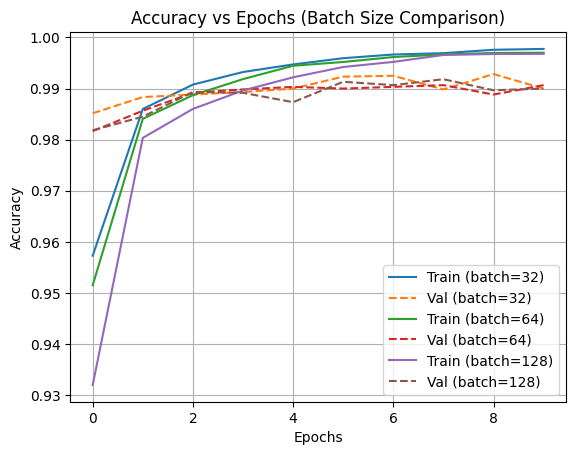

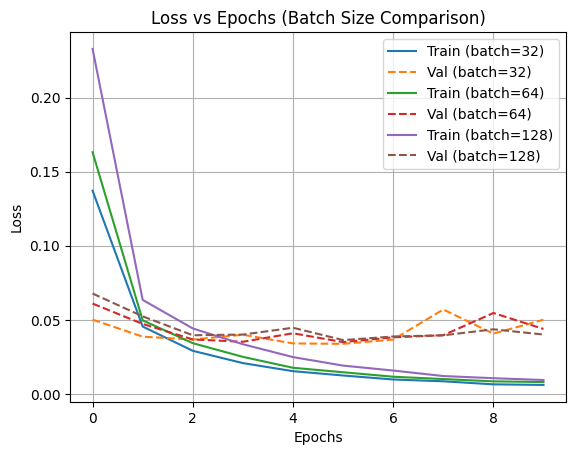


🔹 Final Test Accuracies:
Batch Size 32: 0.9875
Batch Size 64: 0.9904
Batch Size 128: 0.9901


In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# Batch sizes to test
batch_sizes = [32, 64, 128]

# Store histories
histories = {}
test_accuracies = {}

for batch in batch_sizes:
    print(f"\n🔹 Training with batch size = {batch}\n")

    # Create model (fresh model each time)
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train
    history = model.fit(
        X_train_cnn, y_train,
        epochs=10,
        batch_size=batch,
        validation_split=0.1,
        verbose=1
    )

    # Evaluate
    test_loss, test_acc = model.evaluate(X_test_cnn, y_test, verbose=0)
    print(f"✅ Test accuracy (batch {batch}): {test_acc}")

    # Store results
    histories[batch] = history
    test_accuracies[batch] = test_acc

# 📊 Accuracy Comparison

plt.figure()
for batch in batch_sizes:
    plt.plot(histories[batch].history['accuracy'], label=f'Train (batch={batch})')
    plt.plot(histories[batch].history['val_accuracy'], linestyle='--', label=f'Val (batch={batch})')

plt.title("Accuracy vs Epochs (Batch Size Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# 📉 Loss Comparison

plt.figure()
for batch in batch_sizes:
    plt.plot(histories[batch].history['loss'], label=f'Train (batch={batch})')
    plt.plot(histories[batch].history['val_loss'], linestyle='--', label=f'Val (batch={batch})')

plt.title("Loss vs Epochs (Batch Size Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# 📌 Final Comparison

print("\n🔹 Final Test Accuracies:")
for batch in batch_sizes:
    print(f"Batch Size {batch}: {test_accuracies[batch]:.4f}")

# removed the hidden layer with 128 neurons

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 98ms/step - accuracy: 0.9152 - loss: 0.3005 - val_accuracy: 0.9732 - val_loss: 0.0864
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9750 - loss: 0.0836 - val_accuracy: 0.9807 - val_loss: 0.0677
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9815 - loss: 0.0609 - val_accuracy: 0.9850 - val_loss: 0.0506
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 97ms/step - accuracy: 0.9852 - loss: 0.0489 - val_accuracy: 0.9863 - val_loss: 0.0467
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 105ms/step - accuracy: 0.9876 - loss: 0.0415 - val_accuracy: 0.9870 - val_loss: 0.0428
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9889 - loss: 0.0357 - val_accuracy: 0.9877 - val_loss: 0.0409
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - accuracy: 0.9904 - loss: 0.0311 - val_accuracy: 0.9887 - val_loss: 0.0387
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9916 - loss: 0.027

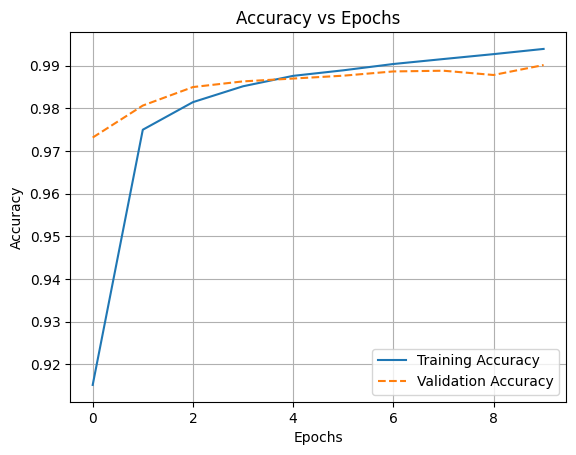

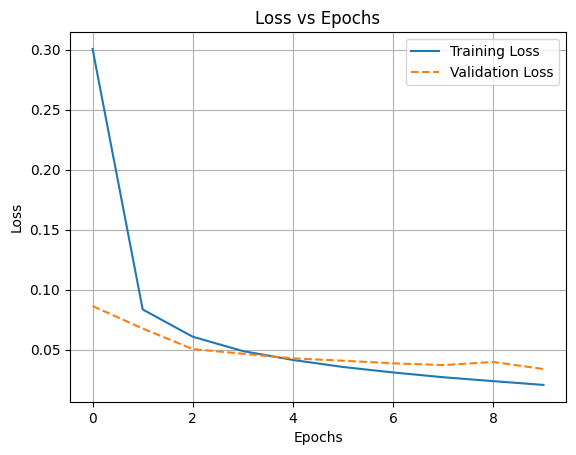

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# reshape for CNN
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

# Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 🔹 Store training history
history = model.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print("Test accuracy:", test_acc)

# 📊 Accuracy Graph

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], linestyle='--', label='Validation Accuracy')

plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# 📉 Loss Graph

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], linestyle='--', label='Validation Loss')

plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()